# Full end to end


### 1. Import Libraries


In [37]:
import numpy as np 
import pandas as pd

In [38]:
import matplotlib.pyplot as plt

In [39]:
print("Hello")

Hello


In [40]:
df = pd.read_csv("C:/Users/Garv/Desktop/ml nbs/datasets/02_placement.csv")

In [41]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [42]:
df.shape

(100, 4)

In [43]:
df = df.iloc[:,1:] # iloc used when accesing by index and loc when accesing by label
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# Visualizing

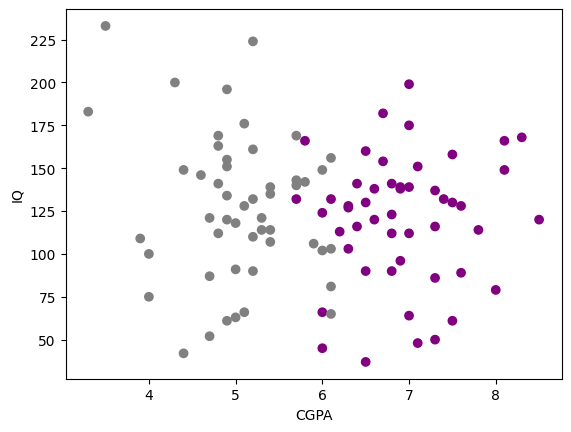

In [45]:
# plt.scatter(df['cgpa'],df['iq'], c  = df['placement'])
# plt.show()
# # yellow -> placed
# # black -> not placed

# or 

colors = df['placement'].map({0: 'grey', 1: 'purple'})

plt.scatter(df['cgpa'], df['iq'], c=colors)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

## Creating separate datasets for training and testing

In [46]:
X = df.iloc[:,:2]
Y = df.iloc[:,2:]

In [47]:
X.head()


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [48]:
Y.head()


,placement
0,1
1,0
2,0
3,1
4,0


## Train test split

In [49]:
from sklearn.model_selection import train_test_split
    
# train_test_split(X,Y,test_size=0.15)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.15)


In [50]:
Y_test.head()

,placement
9,0
57,1
56,0
28,0
68,0


In [51]:
X_train.head()

,cgpa,iq
45,6.0,66.0
77,7.3,50.0
1,5.9,106.0
40,4.9,134.0
82,6.5,37.0


## Scaling


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
X_test

array([[-0.85779324, -1.50316129],
       [ 0.38553679,  0.09114509],
       [ 0.03029964, -1.52807233],
       [-0.76898395, -0.9052964 ],
       [-1.83469541, -1.27896196],
       [-1.1242211 ,  1.06267554],
       [-0.94660253, -1.57789441],
       [ 1.18482038,  0.14096716],
       [-0.85779324,  0.04132301],
       [-0.05850965, -0.60636395],
       [-1.1242211 ,  0.91320932],
       [ 0.20791822,  0.01641198],
       [-0.68017466, -0.13305425],
       [-1.9235047 , -0.43198669],
       [ 1.71767611, -1.17931781]])

In [55]:
dfX = pd.DataFrame(X_train)
dfX.head()

,0,1
0,-0.058510,-1.503161
1,1.096011,-1.901738
2,-0.147319,-0.506720
3,-1.035412,0.190789
4,0.385537,-2.225581


In [56]:
Y_test

,placement
9,0
57,1
56,0
28,0
68,0
75,0
7,0
3,1
86,0
62,0


## Model


In [57]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [58]:
clf.fit(X_train,Y_train)

c:\Users\Garv\Desktop\ml nbs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluate

In [59]:
Y_pred = clf.predict(X_test)
print(Y_pred)

[0 1 1 0 0 0 0 1 0 1 0 1 0 0 1]


In [60]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.8666666666666667

In [61]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

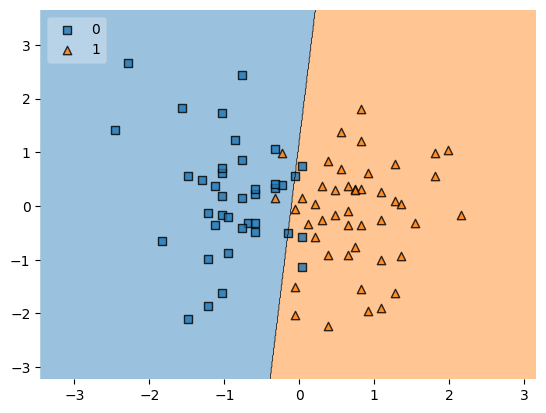

In [62]:
plot_decision_regions(
    X_train,
    Y_train.values.ravel(), # .values() convert dataframe/series to numpy array # rave1() -> flatten array to 1 d
    clf=clf,
    legend=2
)

In [63]:
import pickle


In [66]:
pickle.dump(clf,open("model.pkl",'wb'))

In [ ]:
model = pickle.load(open("model.pkl","rb"))
prediction = model.predict(X_test)

print(prediction)

[1 1 1 1 1 1 0 0 0 0 1 0 1 1 0]


In [ ]:
print(Y_pred)


[1 1 1 1 1 1 0 0 0 0 1 0 1 1 0]
